# GSIN vs UPC: what lot-level scan data actually buys the filter

**Question.** GSIN (lot-resolved scanning) should give the particle filter strictly more
information than UPC (aggregate totals). It was doing the opposite: more diffuse beliefs
and large phantom inventory. Why, and what does GSIN buy once that is fixed?

**Setup.** For each seed, one physics episode is simulated under a fixed exogenous order
script, so *every* observation channel sees the identical ground truth (common random
numbers). The richest day log is then replayed through each `ObsMask`, and the resulting
belief is compared with truth.

| Rung | `code_type` | `scan_waste` | `delivery_history` |
|------|-------------|--------------|--------------------|
| P0 | upc | off | none |
| P1 | upc | on | none |
| F1 | **gsin** | on | none |
| F2a | upc | on | pack date |
| F2 | **gsin** | on | pack date |
| F3 | **gsin** | on | temperature trace |

`P1 → F1` and `F2a → F2` are the clean UPC↔GSIN contrasts: same waste and delivery
channels, only the code type changes.

**Data.** `experiments/data/*.json`, produced by
`cargo run -p voi_core --release --example gsin_upc_diag`. The *before* files come from
the same harness run on `team/T-137/implement` (pre-ADR-0137); the *after* files from this
branch. Regenerate the after side with `experiments/regen_gsin_upc_data.sh`.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

DATA = Path("..") / "experiments" / "data"
if not DATA.exists():  # notebook executed from the repo root
    DATA = Path("experiments") / "data"

before = json.loads((DATA / "gsin_upc_before.json").read_text())
after = json.loads((DATA / "gsin_upc_after.json").read_text())
voi_before = json.loads((DATA / "voi_profits_before.json").read_text())
voi_after = json.loads((DATA / "voi_profits_after.json").read_text())

RUNGS = ["P0", "P1", "F1", "F2a", "F2", "F3"]
GSIN = {"F1", "F2", "F3"}
REGIMES = [r["regime"] for r in after]
REGIMES = list(dict.fromkeys(REGIMES))

# Categorical slots 1-3 of the validated default palette (all-pairs clean, light mode).
C_BEFORE, C_AFTER, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, INK_3 = "#0b0b0b", "#52514e", "#8a8985"

mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": INK_3,
    "axes.linewidth": 0.8,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": INK,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "font.size": 10,
    "figure.dpi": 120,
})


def pick(rows, regime):
    """Rows for one regime, keyed by rung."""
    return {r["channel"]: r for r in rows if r["regime"] == regime}


def grouped_bars(ax, labels, series, colors, fmt="{:.2f}", ylabel="", legend=True,
                 label_size=7.5, stagger=0.0):
    """Grouped bars with a surface gap and a direct label on every bar.

    Labels are mandatory rather than decorative: two palette slots sit below 3:1
    contrast on this surface, so identity must not rest on colour alone.
    """
    n = len(series)
    x = np.arange(len(labels))
    width = 0.8 / n
    for i, ((name, vals), color) in enumerate(zip(series.items(), colors)):
        off = (i - (n - 1) / 2) * width
        bars = ax.bar(x + off, vals, width * 0.92, label=name, color=color,
                      edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
        for b, v in zip(bars, vals):
            above = v >= 0
            dy = (4 if above else -11) + (stagger if i % 2 else 0.0) * (1 if above else -1)
            ax.annotate(fmt.format(v),
                        (b.get_x() + b.get_width() / 2, b.get_height()),
                        textcoords="offset points", xytext=(0, dy),
                        ha="center", fontsize=label_size, color=INK_2)
    ax.set_xticks(x, labels)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)
    ax.margins(y=0.20)
    if n > 1 and legend:
        ax.legend(frameon=False, fontsize=9, loc="upper left")


print(f"{len(REGIMES)} regimes:")
for r in REGIMES:
    print(" -", r)

3 regimes:
 - Homogeneous fleet, overlapping lots
 - Heterogeneous fleet, overlapping lots
 - Heterogeneous fleet, deep shelf


## 1. The defect: GSIN believed in inventory that was not there

`count_bias` is the mean signed error of the belief's expected live-unit count against
truth, averaged over days after burn-in. Positive means the filter thinks the shelf holds
more than it does.

Before the fix, the GSIN rungs carried **+24 to +29 units** of phantom mass. The mechanism
was not statistical: the filter partitioned each particle row into fixed `units_per_lot`
chunks while truth appends one variable-width segment per delivery. Once those partitions
diverged, `waste_by.len() != n_lots` made the lot-resolved likelihood return `-inf` for
every particle, the weights normalised to uniform, and GSIN ran as a blind bootstrap
filter — with a fixed-width drain on each arrival inflating the row every delivery.

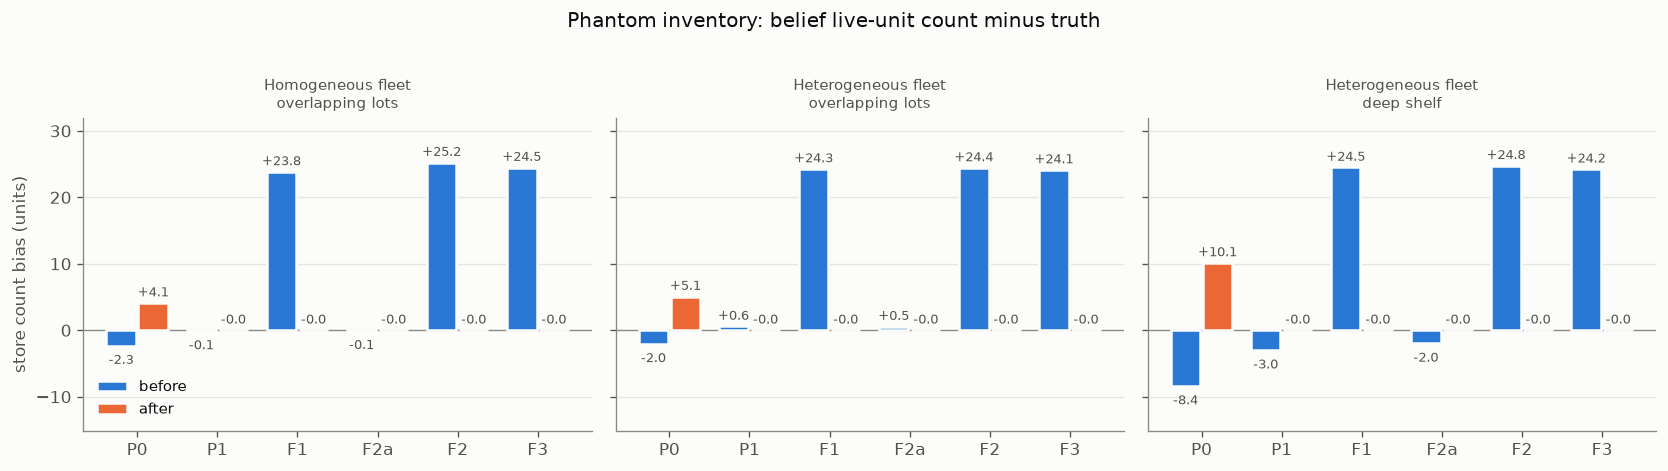

In [2]:
fig, axes = plt.subplots(1, len(REGIMES), figsize=(14, 3.8), sharey=True)
for ax, regime in zip(axes, REGIMES):
    b, a = pick(before, regime), pick(after, regime)
    grouped_bars(
        ax, RUNGS,
        {"before": [b[k]["count_bias"] for k in RUNGS],
         "after": [a[k]["count_bias"] for k in RUNGS]},
        [C_BEFORE, C_AFTER], fmt="{:+.1f}", legend=False,
    )
    ax.axhline(0, color=INK_3, linewidth=0.8, zorder=2)
    ax.set_title(regime.replace(", ", "\n"), fontsize=9, color=INK_2)
axes[0].set_ylabel("store count bias (units)")
axes[0].legend(frameon=False, fontsize=9, loc="lower left")
fig.suptitle("Phantom inventory: belief live-unit count minus truth", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

After the fix the bias is **exactly zero** for every rung that observes spoilage.

That is not a tuning result, it is conservation. With an empty shelf at day 0, observed
arrivals, observed sales, and a spoilage step that samples the daily decrement *from the
interval the observation implies*, every particle satisfies

```
alive_t = alive_{t-1} - waste_t - sales_t + arrivals_t
```

exactly. P0 is the one rung left with count uncertainty, because it never sees waste — and
its residual is now honest posterior spread rather than a mechanical drain (see §5).

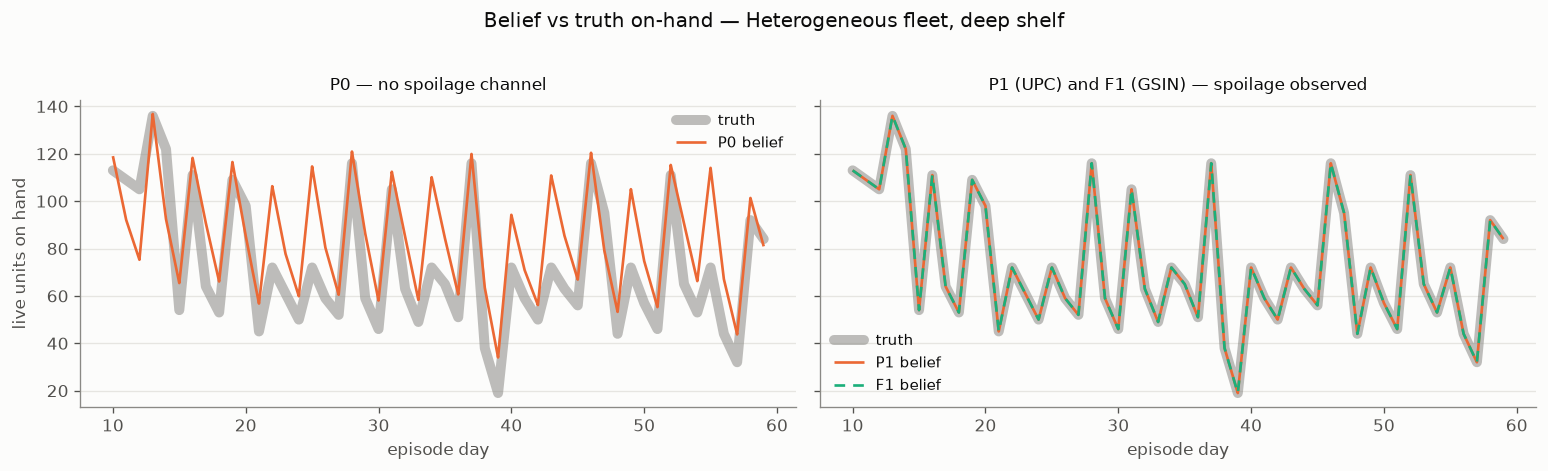

In [3]:
regime = REGIMES[-1]  # deep shelf: the hardest case
a = pick(after, regime)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, rungs, title in [
    (axes[0], ["P0"], "P0 — no spoilage channel"),
    (axes[1], ["P1", "F1"], "P1 (UPC) and F1 (GSIN) — spoilage observed"),
]:
    s = a[rungs[0]]["series"]
    # Truth as a wide pale band: the lot-resolved beliefs land exactly on it, and a
    # thin line would simply be hidden underneath them.
    ax.plot(s["day"], s["truth_on_hand"], color=INK_3, linewidth=6, alpha=0.55,
            solid_capstyle="round", label="truth", zorder=2)
    for rung, color, dash in zip(rungs, [C_AFTER, C_THIRD], [(None, None), (4, 3)]):
        s = a[rung]["series"]
        ax.plot(s["day"], s["belief_on_hand"], color=color, linewidth=1.6,
                dashes=dash if dash[0] else (1, 0),
                label=f"{rung} belief", zorder=3 + rungs.index(rung))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("episode day")
    ax.grid(axis="y")
    ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=9)
axes[0].set_ylabel("live units on hand")
fig.suptitle(f"Belief vs truth on-hand — {regime}", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

P1 and F1 sit exactly on truth (the lines are indistinguishable). P0 traces a smooth
sawtooth through truth's lumpy one: a whole delivery cohort is born at one freshness and
therefore spoils on a single day, and without a waste channel P0 can only average over when
that happens.

## 2. What GSIN actually buys: attribution, not level

With the counts pinned, the honest comparison is *per lot*. Both channels observe the
delivery stream, so the bank's j-th-newest segment is truth's j-th-newest lot for either
one; the metrics below align on that. Only GSIN additionally learns which lot each sale and
each spoil came from.

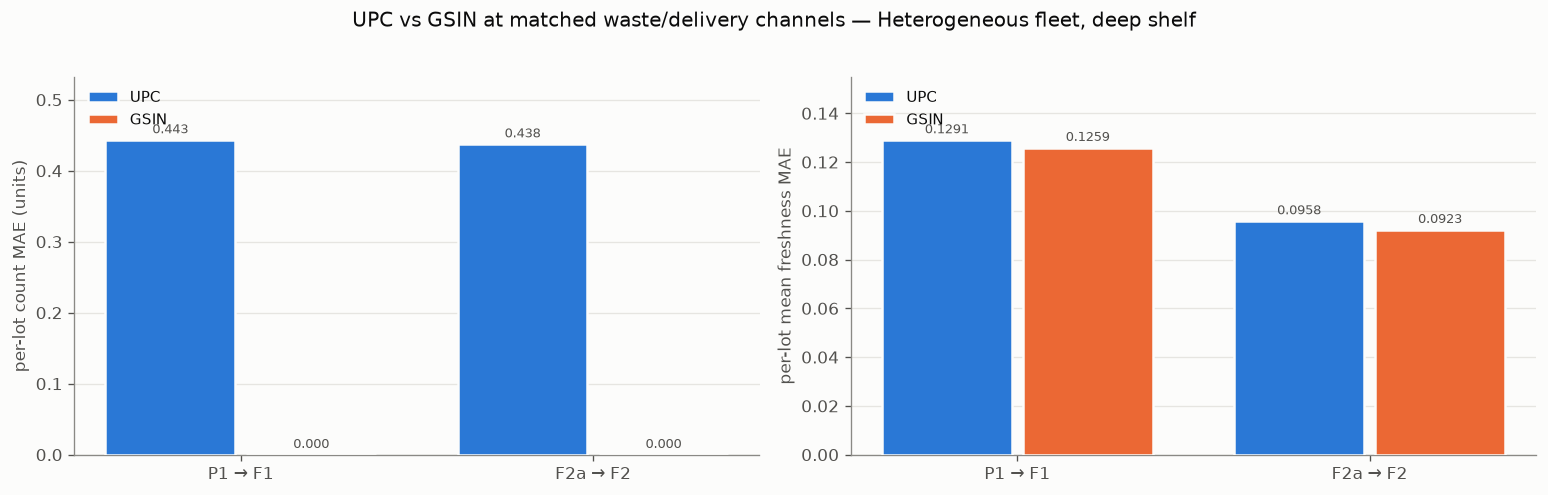

pair         metric                          UPC       GSIN
P1 → F1      lot_count_mae                0.4434     0.0000
P1 → F1      lot_mean_f_mae               0.1291     0.1259
P1 → F1      store_mean_f_mae             0.1188     0.1173
P1 → F1      eff_inv_mae                  8.4975     8.3400
P1 → F1      ess                        147.6570   158.0110
F2a → F2     lot_count_mae                0.4376     0.0000
F2a → F2     lot_mean_f_mae               0.0958     0.0923
F2a → F2     store_mean_f_mae             0.0883     0.0868
F2a → F2     eff_inv_mae                  6.2532     6.1012
F2a → F2     ess                        151.2820   161.8940


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
regime = REGIMES[-1]
a = pick(after, regime)
pairs = [("P1", "F1"), ("F2a", "F2")]
labels = [f"{u} → {g}" for u, g in pairs]
for ax, key, ylab, fmt in [
    (axes[0], "lot_count_mae", "per-lot count MAE (units)", "{:.3f}"),
    (axes[1], "lot_mean_f_mae", "per-lot mean freshness MAE", "{:.4f}"),
]:
    grouped_bars(
        ax, labels,
        {"UPC": [a[u][key] for u, _ in pairs], "GSIN": [a[g][key] for _, g in pairs]},
        [C_BEFORE, C_AFTER], fmt=fmt, ylabel=ylab,
    )
fig.suptitle(f"UPC vs GSIN at matched waste/delivery channels — {regime}",
             y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

print(f"{'pair':<12} {'metric':<24} {'UPC':>10} {'GSIN':>10}")
for u, g in pairs:
    for key in ("lot_count_mae", "lot_mean_f_mae", "store_mean_f_mae", "eff_inv_mae", "ess"):
        print(f"{u+' → '+g:<12} {key:<24} {a[u][key]:>10.4f} {a[g][key]:>10.4f}")

**Per-lot inventory becomes exact under GSIN** (MAE `0.000` vs `0.22–0.44` for UPC): once
sales and spoils are attributed to named lots, the per-lot count is conserved the same way
the store total is. That is the channel's headline value.

The freshness *level* improves only slightly (a few percent). This is the physically honest
answer and worth stating plainly:

- Picking is only weakly freshness-dependent (`sigma = 0.5`), so the cross-lot sales split
  is a weak signal about relative freshness.
- Per-lot spoilage adds little over the store total, because a cohort spoils all at once —
  given the total, *which* lot it came from is usually already determined.

Freshness level is bought by the **`delivery_history`** axis instead, which is exactly the
orthogonality ADR 0133 designs for: `code_type` resolves *where the stock is*,
`delivery_history` resolves *how fresh it is*.

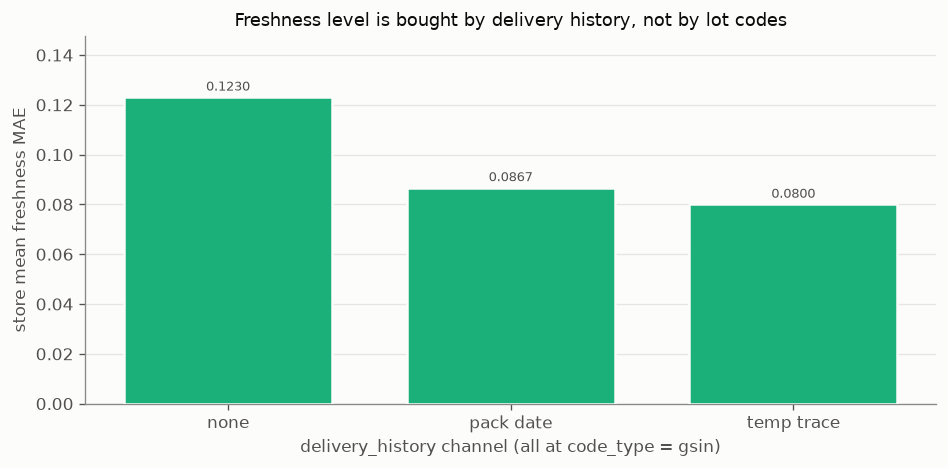

In [5]:
regime = REGIMES[1]  # heterogeneous fleet: delivery history has something to explain
a = pick(after, regime)
fig, ax = plt.subplots(figsize=(8, 4))
grouped_bars(
    ax, ["none", "pack date", "temp trace"],
    {"store mean-f MAE": [a["F1"]["store_mean_f_mae"], a["F2"]["store_mean_f_mae"],
                          a["F3"]["store_mean_f_mae"]]},
    [C_THIRD], fmt="{:.4f}", ylabel="store mean freshness MAE",
)
ax.set_xlabel("delivery_history channel (all at code_type = gsin)")
ax.set_title("Freshness level is bought by delivery history, not by lot codes", fontsize=11)
fig.tight_layout()
plt.show()

## 3. Before and after, every metric

`lot_mean_f_mae` before the fix is dominated by the misalignment itself — the filter's
"lot 2" was not truth's lot 2 — so the before/after gap on the per-lot metrics measures the
bug, not a modelling improvement.

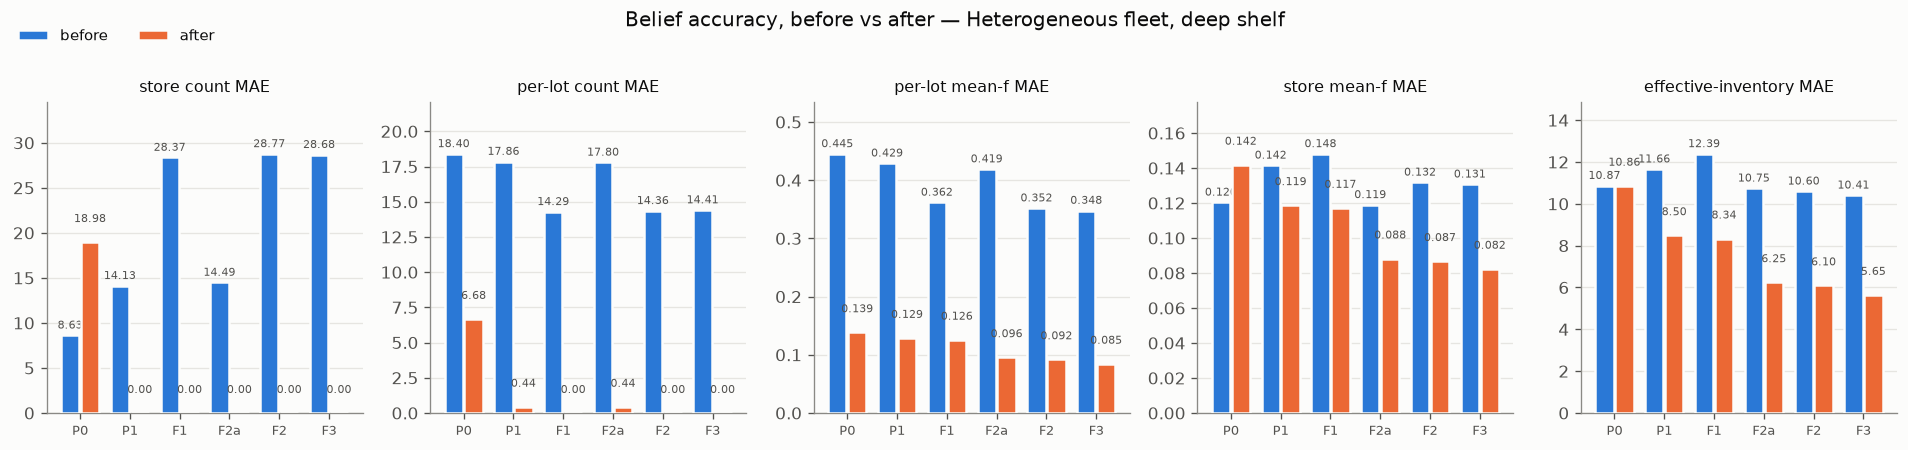

In [6]:
KEYS = [
    ("count_mae", "store count MAE", "{:.2f}"),
    ("lot_count_mae", "per-lot count MAE", "{:.2f}"),
    ("lot_mean_f_mae", "per-lot mean-f MAE", "{:.3f}"),
    ("store_mean_f_mae", "store mean-f MAE", "{:.3f}"),
    ("eff_inv_mae", "effective-inventory MAE", "{:.2f}"),
]
regime = REGIMES[-1]
b, a = pick(before, regime), pick(after, regime)
fig, axes = plt.subplots(1, len(KEYS), figsize=(16, 3.6))
for ax, (key, title, fmt) in zip(axes, KEYS):
    grouped_bars(
        ax, RUNGS,
        {"before": [b[k][key] for k in RUNGS], "after": [a[k][key] for k in RUNGS]},
        [C_BEFORE, C_AFTER], fmt=fmt, legend=False, label_size=6.8, stagger=8.0,
    )
    ax.set_title(title, fontsize=9.5)
    ax.tick_params(axis="x", labelsize=8)
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, frameon=False, fontsize=9, ncol=2,
           loc="upper left", bbox_to_anchor=(0.005, 1.02))
fig.suptitle(f"Belief accuracy, before vs after — {regime}", y=1.03, fontsize=12)
fig.tight_layout()
plt.show()

## 4. The closed loop

Belief accuracy only matters if it survives into orders. `run_voi_crn_cell` runs the full
controller (damped survival-weighted base stock + rollout) under each mask on shared
physics and scores realised profit.

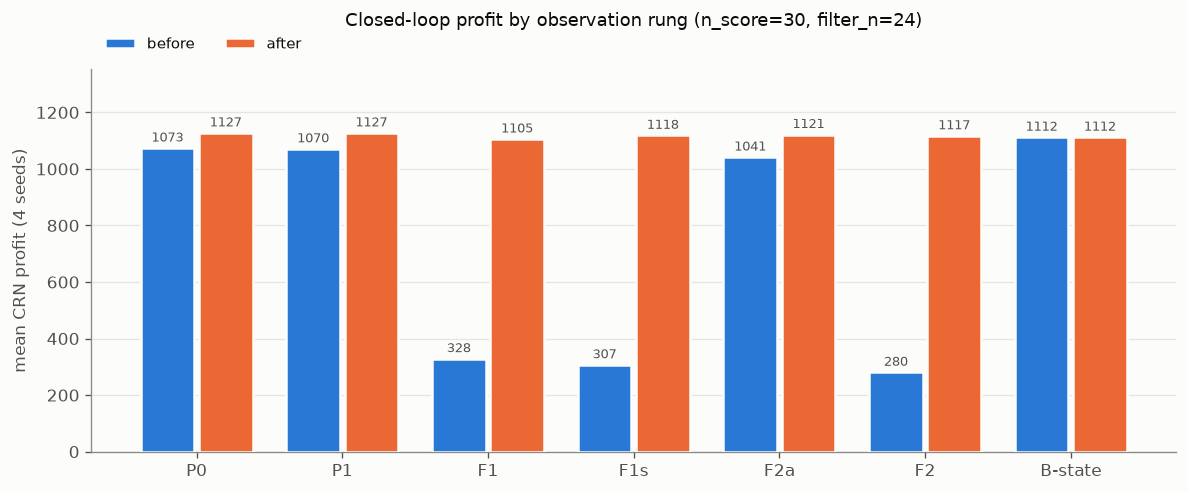

rung         before     after    change
P0           1073.2    1126.9     +53.6
P1           1070.5    1126.9     +56.4
F1            328.4    1105.2    +776.9
F1s           306.8    1118.2    +811.5
F2a          1041.4    1121.2     +79.9
F2            280.2    1116.6    +836.4
B-state      1111.8    1111.8      +0.0


In [7]:
SCEN = ["P0", "P1", "F1", "F1s", "F2a", "F2", "B-state"]


def mean_profit(rows):
    out = {}
    for s in SCEN:
        vals = [r["profit"] for r in rows if r["scenario"] == s]
        out[s] = float(np.mean(vals))
    return out


pb, pa = mean_profit(voi_before), mean_profit(voi_after)
fig, ax = plt.subplots(figsize=(10, 4.2))
grouped_bars(
    ax, SCEN,
    {"before": [pb[s] for s in SCEN], "after": [pa[s] for s in SCEN]},
    [C_BEFORE, C_AFTER], fmt="{:.0f}", ylabel="mean CRN profit (4 seeds)", legend=False,
)
ax.legend(frameon=False, fontsize=9, ncol=2, loc="lower left",
          bbox_to_anchor=(0.0, 1.01))
ax.set_title("Closed-loop profit by observation rung (n_score=30, filter_n=24)",
             fontsize=11, pad=26)
fig.tight_layout()
plt.show()

print(f"{'rung':<9} {'before':>9} {'after':>9} {'change':>9}")
for s in SCEN:
    print(f"{s:<9} {pb[s]:>9.1f} {pa[s]:>9.1f} {pa[s] - pb[s]:>+9.1f}")

Before the fix the GSIN rungs earned roughly **a third** of the UPC rungs' profit — a filter
running blind produces a belief the controller cannot use. After, every rung lands within a
few percent of the others and of the `B-state` oracle.

**Caveat, and it is a real one.** Profit is still not monotone in information: `P0` is not
reliably the worst and the `B-state` oracle is not reliably the best. Because the oracle
uses ground truth directly and *still* underperforms, that ordering is a property of the
policy and cost structure (lost-sale 3.0 vs waste 1.5 rewards over-ordering), not of the
filter. It needs a controller/α-tuning ticket; it is out of scope for the filter fix.

## 5. Cost, and what is left

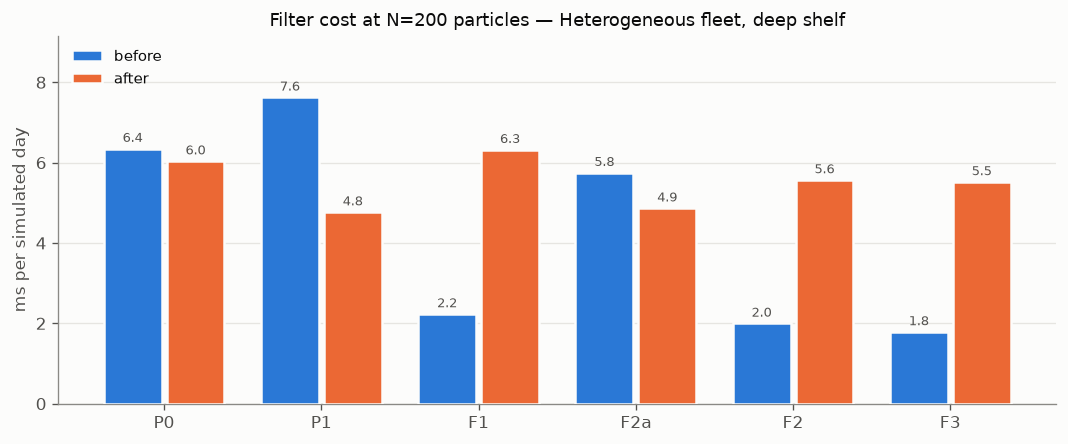

In [8]:
regime = REGIMES[-1]
b, a = pick(before, regime), pick(after, regime)
fig, ax = plt.subplots(figsize=(9, 3.8))
grouped_bars(
    ax, RUNGS,
    {"before": [b[k]["ms_per_day"] for k in RUNGS],
     "after": [a[k]["ms_per_day"] for k in RUNGS]},
    [C_BEFORE, C_AFTER], fmt="{:.1f}", ylabel="ms per simulated day",
)
ax.set_title(f"Filter cost at N=200 particles — {regime}", fontsize=11)
fig.tight_layout()
plt.show()

Runtime is unchanged in order (single-digit ms/day at N=200, against a 500 ms studio
budget). The GSIN rungs look *slower* than before only because their likelihood used to
short-circuit to `-inf` before doing any work.

### Open items

1. **P0 count bias.** P0 has no spoilage channel, and its only sales constraint is
   one-sided (`alive >= sales`), so over-stocked particles are never penalised. The
   principled fix is a demand-censoring term — score `P(D >= sales)` rather than
   `P(D = sales)` when a particle stocks out — which needs the calendar day threaded into
   `filter_step_unit`.
2. **Cross-lot allocation is multinomial, not Wallenius.** Deliberate first-order
   approximation (ADR 0135), validated at small and realistic lot counts. It matters little
   here because `sigma = 0.5` makes the signal weak either way.
3. **VOI monotonicity** — see the caveat in §4. Policy/cost issue, not a filter issue.
4. **Legacy waste primitives** (`p1_totals_loglik`, `loglik_waste_by_units`,
   `loglik_waste_tot_after_sales_by`) are off the production path but still exported for
   PyO3 parity tests. Removing them is a follow-up.